2026-05-19 10:43:38,592[INFO] Use NumPy as backend
2026-05-19 10:43:38,595[INFO] numpy random seed is 9012
2026-05-19 10:43:38,596[INFO] random seed is 1092
2026-05-19 10:43:38,830[INFO] Git Commit Hash: b3169b789efcfbc3c292046a90309524d429aaeb
2026-05-19 10:43:38,834[INFO] use 64 bits


成功加载数据，长度: 6


/curie-home/zengjj/.conda/envs/renormalizer/lib/python3.8/site-packages/matplotlib/cbook/__init__.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


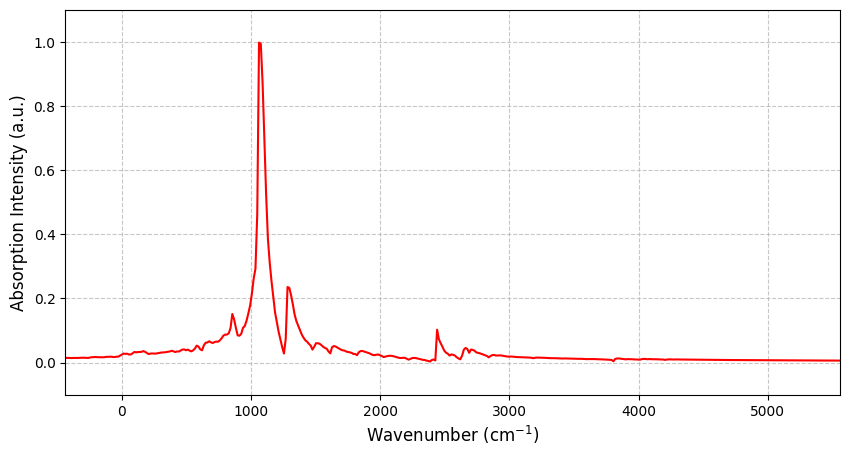

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant
# ================= 配置参数 (需与 run_monomer.py 一致) =================
           
# ======================================================================
def autocorr_to_spectrum(path="" ):
    try:
        data = np.load(path)
        print(f"成功加载数据，长度: {len(data)}")
    except:
        print("错误：未找到 autocorr_data.npy 文件！")
        return

    times_au = data["time series"]
    dt_au = times_au[1] - times_au[0]

    autocorr = np.asarray(data["autocorr"])

    # freq: 1/au (Hartree)
    spectrum = np.fft.fft(autocorr)
    freqs_hartree = - np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    
    # Offset (eV)
    freqs_cm = freqs_hartree * constant.au2cm
    
    intensities = np.abs(spectrum)/np.max(spectrum)

    # 数据筛选 (只取正频率附近的结果)
    # 排序以方便画图
    idx = np.argsort(freqs_cm)
    x = freqs_cm[idx]
    y = intensities[idx]

    plt.figure(figsize=(10, 5))

    peak_pos = x[np.argmax(y)]
    plt.xlim(peak_pos - 1500, peak_pos + 4500)
    plt.ylim(-0.1,1.1)
    plt.plot(x, y, color='red', linewidth=1.5)

    plt.xlabel("Wavenumber (cm$^{-1}$)", fontsize=12)
    plt.ylabel("Absorption Intensity (a.u.)", fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 保存结果
    # plt.savefig(f"monomer_spectrum.png", dpi=300)
    plt.show()

if __name__ == "__main__":
    autocorr_to_spectrum(path="../multiset/pbi_trimer_ft_ancilla_emi_multiset.npz")
    # "../multiset/pbi_dimer.npz"

2026-05-05 20:40:32,162[INFO] Using GPU: 0
2026-05-05 20:40:32,165[INFO] Use CuPy as backend
2026-05-05 20:40:32,166[INFO] cupy random seed is 2019
2026-05-05 20:40:32,167[INFO] random seed is 1092
2026-05-05 20:40:32,217[INFO] Git Commit Hash: 9e4f5dfa43096053fecf425a65c353443025315a
2026-05-05 20:40:32,219[INFO] use 64 bits


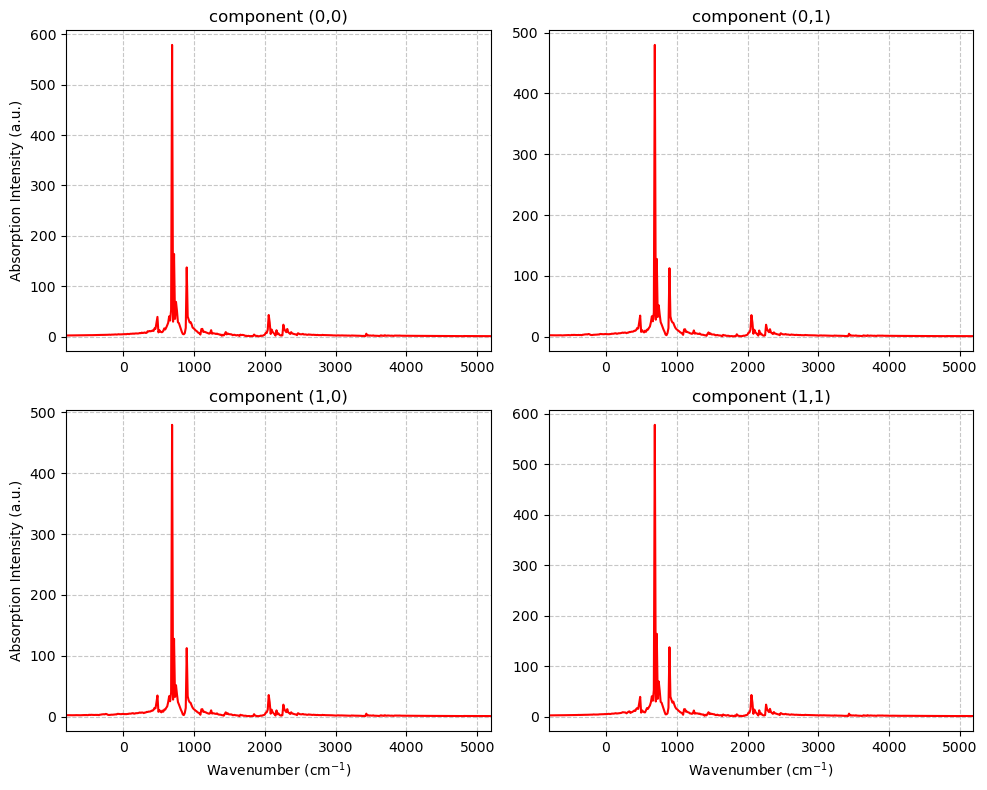

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from renormalizer.utils import constant

path = "../multiset/pbi_trimerr_ft_emi_multiset.npz"
data = np.load(path)
times_au = data["time series"]
dt_au = times_au[1] - times_au[0]

autocorr_components = np.asarray(data["autocorr_components"])

def autocorr_to_spectrum_no_broadening(autocorr):
    spectrum = np.fft.fft(autocorr)
    freqs_hartree = -np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    freqs_cm = freqs_hartree * constant.au2cm
    intensities = np.abs(spectrum) # np.abs(spectrum) / np.max(np.abs(spectrum))
    idx = np.argsort(freqs_cm)
    return freqs_cm[idx], intensities[idx]

def plot_component(ax, x, y, title):
    peak_pos = x[np.argmax(y)]
    ax.plot(x, y, color='red', linewidth=1.5)
    ax.set_xlim(peak_pos - 1500, peak_pos + 4500)
    ax.set_title(title, fontsize=12)
    ax.grid(True, linestyle='--', alpha=0.7)

n_bra, n_ket = autocorr_components.shape[1], autocorr_components.shape[2]
fig, axes = plt.subplots(n_bra, n_ket, figsize=(5 * n_ket, 4 * n_bra), squeeze=False)

for i in range(n_bra):
    for j in range(n_ket):
        x_c, y_c = autocorr_to_spectrum_no_broadening(autocorr_components[:, i, j])
        ax = axes[i, j]
        plot_component(ax, x_c, y_c, f"component ({i},{j})")
        if i == n_bra - 1:
            ax.set_xlabel("Wavenumber (cm$^{-1}$)", fontsize=10)
        if j == 0:
            ax.set_ylabel("Absorption Intensity (a.u.)", fontsize=10)

plt.tight_layout()
plt.show()

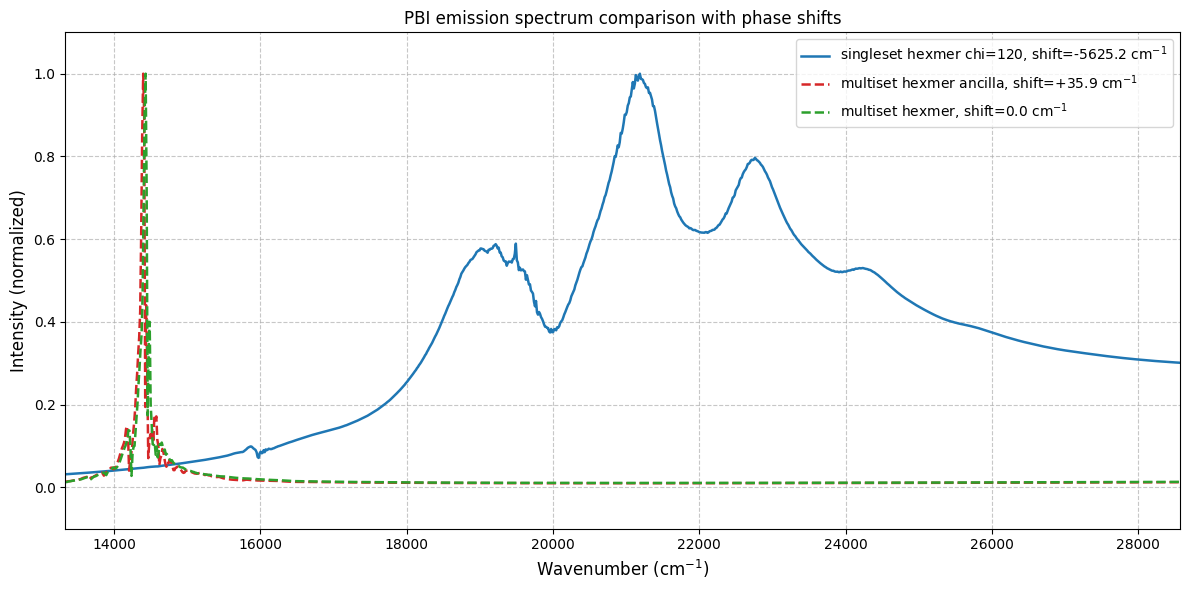

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from renormalizer.utils import constant


def autocorr_to_spectrum(
    path,
    t_gaussian_fs=None,
    offset_ev=2.13 - 0.086,
    spectratype="emi",
    apply_prefactor=True,
    phase_shift_cm=0.0,
    xlim_cm=None,
):
    data = np.load(path)
    time_key = "time_series" if "time_series" in data else "time series"
    times_au = data[time_key]
    dt_au = times_au[1] - times_au[0]
    autocorr = np.asarray(data["autocorr"])
    t_axis = times_au - times_au[0]

    if t_gaussian_fs is None:
        broadening_filter = np.ones_like(t_axis, dtype=float)
    else:
        t_gaussian_au = t_gaussian_fs * constant.fs2au
        broadening_filter = np.exp(-(t_axis / t_gaussian_au) ** 2)
    c_t_broadened = autocorr * broadening_filter

    spectrum = np.fft.fft(c_t_broadened)
    fft_freqs_au = np.fft.fftfreq(len(autocorr), d=dt_au) * 2 * np.pi
    offset_au = offset_ev * constant.ev2au

    if spectratype == "abs":
        freqs_au = offset_au - fft_freqs_au
    elif spectratype == "emi":
        freqs_au = offset_au + fft_freqs_au
    else:
        raise ValueError("spectratype should be 'abs' or 'emi'")

    freqs_cm = freqs_au * constant.au2cm + phase_shift_cm
    shifted_freqs_au = freqs_cm / constant.au2cm

    intensities = np.abs(spectrum)
    if apply_prefactor:
        if spectratype == "abs":
            intensities *= shifted_freqs_au
        elif spectratype == "emi":
            intensities *= shifted_freqs_au ** 3

    positive_freq = freqs_cm > 0
    freqs_cm = freqs_cm[positive_freq]
    intensities = intensities[positive_freq]

    if xlim_cm is not None:
        visible = (freqs_cm >= xlim_cm[0]) & (freqs_cm <= xlim_cm[1])
        freqs_cm = freqs_cm[visible]
        intensities = intensities[visible]

    max_intensity = np.max(intensities)
    if max_intensity != 0:
        intensities = intensities / max_intensity

    idx = np.argsort(freqs_cm)
    return freqs_cm[idx], intensities[idx]


xlim_cm = (1e7 / 750, 1e7 / 350)
spectra_specs = [
    {
        "path": "../../../multiset_202604/spetra_ft_pbi/singleset/pbi_hexmer_ft_emi_120bd.npz",
        "label": "singleset hexmer chi=120, shift=-5625.2 cm$^{-1}$",
        "color": "#1f77b4",
        "linestyle": "-",
        "phase_shift_cm": 0,
    },
    {
        "path": "../multiset/pbi_hexmer_ft_ancilla_emi_multiset.npz",
        "label": "multiset hexmer ancilla, shift=+35.9 cm$^{-1}$",
        "color": "#d62728",
        "linestyle": "--",
        "phase_shift_cm": 35.9,
    },
    {
        "path": "../../pbi_ft/multiset/pbi_hexmer_ft_emi_multiset.npz",
        "label": "multiset hexmer, shift=0.0 cm$^{-1}$",
        "color": "#2ca02c",
        "linestyle": "--",
        "phase_shift_cm": 0.0,
    },
]

missing_paths = [spec["path"] for spec in spectra_specs if not Path(spec["path"]).exists()]
if missing_paths:
    raise FileNotFoundError("Missing spectrum files:\n" + "\n".join(missing_paths))

plt.figure(figsize=(12, 6))
for spec in spectra_specs:
    x, y = autocorr_to_spectrum(
        path=spec["path"],
        offset_ev=2.13 - 0.086,
        spectratype="emi",
        apply_prefactor=True,
        phase_shift_cm=spec["phase_shift_cm"],
        xlim_cm=xlim_cm,
    )
    plt.plot(
        x,
        y,
        color=spec["color"],
        linestyle=spec["linestyle"],
        linewidth=1.8,
        label=spec["label"],
    )

plt.xlim(*xlim_cm)
plt.ylim(-0.1, 1.1)
plt.title("PBI emission spectrum comparison with phase shifts")
plt.xlabel("Wavenumber (cm$^{-1}$)", fontsize=12)
plt.ylabel("Intensity (normalized)", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.7)
plt.legend()
plt.tight_layout()
plt.show()
